# LIBRAIRIES

In [1]:
import numpy as np
import json, random, torch

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# HuggingFace transformers
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [2]:
import nltk
nltk.download('punkt')
!pip install rouge_score

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fcb990e5525e6307389b72ec1f3d9d451c14ac9f150f58cfe6d0cd317d8eb3a3
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#MAX_NEW_TOKEN_LENGTH = 50
MAX_LENGHT_TOKENIZER = 50 # <= 1024 limite GPT-2
BATCH_SIZE = 4

# DATA

In [6]:
folder_path = "/content/drive/MyDrive/genai/"

# Load datasets from your genai folder
with open(f"{folder_path}eval_subset.json", "r") as f:
    eval_subset = json.load(f)

with open(f"{folder_path}train_subset.json", "r") as f:
    train_subset = json.load(f)

print(f"Eval examples: {len(eval_subset)}")
print(f"Train examples: {len(train_subset)}")

Eval examples: 500
Train examples: 5000


In [7]:
train_subset[0]

{'table_id': 'List of 8/9 PM telenovelas of Rede Globo',
 'serialized_table': 'Title : A Favorita',
 'reference': 'A Favorita is the telenovela aired in the 9 pm timeslot.'}

# MODEL

## **Device**

In [8]:
# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## **Model loading**

In [9]:
# Load GPT-2 small model and tokenizer
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Set padding token (important for generation)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model.to(device)

print(f"Model loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded on cuda


## **Generation Function**

In [10]:
def generate_batch(model, tokenizer, input_ids, attention_mask, max_new_tokens):

    """
    Generate text using GPT-2 given a prompt
    """

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    decoded_prompts = tokenizer.batch_decode(input_ids, skip_special_tokens=True)

    cleaned = []
    for p, full in zip(decoded_prompts, decoded_outputs):
        if full.startswith(p):
            cleaned.append(full[len(p):].strip())
        else:
            cleaned.append(full.strip())

    return cleaned

# DATASET

## **Dataset class**

In [11]:
class TableDataset(Dataset):

    def __init__(self, folder_path,split, tokenizer, max_length, few_shot):

        self.root_folder = f"{folder_path}{split}_subset.json"
        with open(self.root_folder, "r") as f:
            self.data = json.load(f)
        self.split = split
        self.few_shot = few_shot
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.samples = []

        counter = 0
        for item in self.data:
            table = item["serialized_table"]
            label = item["reference"]
            self.samples.append(
                {"id" : counter,
                 "table" : table,
                 "label" : label})
            counter += 1

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        if not self.few_shot: # Zero-shot generation

            prompt = self.build_prompt(sample["table"])

        else:                 # Few-shot generation

            few_examples = random.sample(self.data, k=3)
            prompt = self.build_prompt(sample["table"], examples=few_examples)

        # --- INPUT
        inputs = self.tokenizer(
            prompt,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        # --- TARGET
        target = self.tokenizer(
            sample["label"],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "table": sample["table"],
            "prompt": prompt,
            "labels_str": sample["label"],
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": target["input_ids"].squeeze(0)
        }


    # Prompt builder
    def build_prompt(self, serialized_table, examples=None):
        """
        Build a prompt for GPT-2.

        If examples are provided → few-shot
        Otherwise → zero-shot
        """

        prompt = ""

        # few-shot examples
        if examples:
            for ex in examples:
                prompt += f"Table: {ex['serialized_table']}\n"
                prompt += f"Description: {ex['reference']}\n\n"

        # target table
        prompt += f"Table: {serialized_table}\n"
        prompt += "Description:"

        return prompt


In [12]:
train_dataset_zeroshot = TableDataset(
    folder_path, "train", tokenizer,
    MAX_LENGHT_TOKENIZER, few_shot=False)

eval_dataset_zeroshot = TableDataset(
    folder_path, "eval", tokenizer,
    MAX_LENGHT_TOKENIZER, few_shot=False)

In [13]:
train_dataset_zeroshot[1]

{'table': 'Year : 2018 | Player name : Roquan Smith | Position : Linebacker | College : Georgia',
 'prompt': 'Table: Year : 2018 | Player name : Roquan Smith | Position : Linebacker | College : Georgia\nDescription:',
 'labels_str': 'The Chicago Bears recent first round selection (2018) was Roquan Smith, an inside linebacker from Georgia.',
 'input_ids': tensor([50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 10962,    25,  6280,  1058,  2864,
           930,  7853,  1438,  1058,  5564,   421,   272,  4176,   930, 23158,
          1058,  6910, 49978,   930,  5535,  1058,  7859,   198, 11828,    25]),
 'attention_mask': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1]),
 'labels': tensor([50256, 50256, 50256, 50256, 502

# METRICS

## **BERT-Score**

In [14]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device).eval()


def get_embeddings_batch(texts):
    inputs = bert_tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)

    return outputs.last_hidden_state  # (B, seq_len, hidden)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
def bertscore_batch(preds, refs):

    emb_pred = get_embeddings_batch(preds)
    emb_ref = get_embeddings_batch(refs)

    scores = []

    for i in range(len(preds)):

        p = emb_pred[i]  # (len_p, dim)
        r = emb_ref[i]   # (len_r, dim)

        # normalisation
        p = F.normalize(p, dim=1)
        r = F.normalize(r, dim=1)

        sim = torch.mm(p, r.T)

        precision = sim.max(dim=1).values.mean()
        recall = sim.max(dim=0).values.mean()

        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        scores.append(f1.item())

    return sum(scores) / len(scores)

In [16]:
def evaluate_bleu_rouge(loader, model, tokenizer, device, max_new_tokens, log_inter=10):

    model.eval()
    all_bleu_scores = []
    all_rouge1_f1 = []
    all_rouge2_f1 = []
    all_rougel_f1 = []

    with torch.no_grad():

        for idx_bt, batch in enumerate(loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            refs = batch["labels_str"]

            preds = generate_batch(
                model,
                tokenizer,
                input_ids,
                attention_mask,
                max_new_tokens
            )

            bleu, r1_f1, r2_f1, rl_f1 = calculate_bleu_rouge_batch(preds, refs)

            all_bleu_scores.append(bleu)
            all_rouge1_f1.append(r1_f1)
            all_rouge2_f1.append(r2_f1)
            all_rougel_f1.append(rl_f1)

            if len(all_bleu_scores) % log_inter == 0:
                print(f"Batch {idx_bt+1}/{len(loader)} "
                      f"\t-> BLEU: {sum(all_bleu_scores)/len(all_bleu_scores):.4f}"
                      f" ROUGE-L: {sum(all_rougel_f1)/len(all_rougel_f1):.4f}")

    avg_bleu = sum(all_bleu_scores) / len(all_bleu_scores) if all_bleu_scores else 0
    avg_rouge1 = sum(all_rouge1_f1) / len(all_rouge1_f1) if all_rouge1_f1 else 0
    avg_rouge2 = sum(all_rouge2_f1) / len(all_rouge2_f1) if all_rouge2_f1 else 0
    avg_rougel = sum(all_rougel_f1) / len(all_rougel_f1) if all_rougel_f1 else 0

    return avg_bleu, avg_rouge1, avg_rouge2, avg_rougel

In [17]:
def evaluate_bertscore(loader, model, tokenizer, device, max_new_tokens, log_inter=10):

    model.eval()
    all_scores = []

    with torch.no_grad():

        for idx_bt, batch in enumerate(loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            refs = batch["labels_str"]

            preds = generate_batch(
                model,
                tokenizer,
                input_ids,
                attention_mask,
                max_new_tokens
            )

            score = bertscore_batch(preds, refs)
            all_scores.append(score)

            if len(all_scores) % log_inter == 0:
                print(f"Batch {idx_bt+1}/{len(loader)} "
                      f"\t-> BERTScore: {sum(all_scores)/len(all_scores):.4f}")

    return sum(all_scores) / len(all_scores)


## **BLEU / ROUGE**

In [18]:
from nltk.tokenize import word_tokenize
from rouge_score import rouge_scorer

def calculate_bleu_rouge_batch(preds, refs):
    bleu_scores = []
    rouge1_f1_scores = []
    rouge2_f1_scores = []
    rougel_f1_scores = []

    # Initialize RougeScorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    # Define weights for BLEU (standard uniform weights for BLEU-4)
    bleu_weights = (0.25, 0.25, 0.25, 0.25)

    for pred, ref in zip(preds, refs):
        # Tokenize for BLEU: reference needs to be a list of token lists (even for single reference)
        tokenized_ref = [word_tokenize(ref)]
        tokenized_pred = word_tokenize(pred)

        # Calculate BLEU score
        # sentence_bleu handles cases where reference is shorter than n-gram order
        try:
            bleu_score = sentence_bleu(tokenized_ref, tokenized_pred, weights=bleu_weights)
            bleu_scores.append(bleu_score)
        except ZeroDivisionError: # Handle cases where there are no matching ngrams (e.g., empty pred)
            bleu_scores.append(0.0)

        # Calculate ROUGE scores
        scores = scorer.score(ref, pred) # rouge_score expects untokenized strings
        rouge1_f1_scores.append(scores['rouge1'].fmeasure)
        rouge2_f1_scores.append(scores['rouge2'].fmeasure)
        rougel_f1_scores.append(scores['rougeL'].fmeasure)

    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0
    avg_rouge1_f1 = sum(rouge1_f1_scores) / len(rouge1_f1_scores) if rouge1_f1_scores else 0
    avg_rouge2_f1 = sum(rouge2_f1_scores) / len(rouge2_f1_scores) if rouge2_f1_scores else 0
    avg_rougel_f1 = sum(rougel_f1_scores) / len(rougel_f1_scores) if rougel_f1_scores else 0

    return avg_bleu, avg_rouge1_f1, avg_rouge2_f1, avg_rougel_f1

## **Self-BLEU**

In [19]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.tokenize import word_tokenize
import numpy as np

def generate_batch_sampling(
    model,
    tokenizer,
    input_ids,
    attention_mask,
    max_new_tokens,
    temperature=0.8,
    top_p=0.9
):
    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tokenizer.eos_token_id
    )

    decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    decoded_prompts = tokenizer.batch_decode(input_ids, skip_special_tokens=True)

    cleaned = []
    for prompt, full_text in zip(decoded_prompts, decoded_outputs):
        if full_text.startswith(prompt):
            cleaned.append(full_text[len(prompt):].strip())
        else:
            cleaned.append(full_text.strip())

    return cleaned


def compute_self_bleu(predictions_list):
    """
    Self-BLEU mesure la diversité entre plusieurs générations
    pour une même table.

    Self-BLEU bas = générations plus diverses
    Self-BLEU haut = générations très similaires
    """
    self_bleu_scores = []
    bleu_weights = (0.25, 0.25, 0.25, 0.25)

    for preds in predictions_list:
        if len(preds) < 2:
            continue

        scores = []

        for i, hyp in enumerate(preds):
            refs = [p for j, p in enumerate(preds) if j != i]

            tokenized_refs = [word_tokenize(r) for r in refs]
            tokenized_hyp = word_tokenize(hyp)

            try:
                score = sentence_bleu(
                    tokenized_refs,
                    tokenized_hyp,
                    weights=bleu_weights
                )
                scores.append(score)
            except ZeroDivisionError:
                scores.append(0.0)

        self_bleu_scores.append(np.mean(scores))

    mean_self_bleu = np.mean(self_bleu_scores) if self_bleu_scores else 0.0

    print(f"Self-BLEU: {mean_self_bleu:.4f} | lower = more diverse")
    return mean_self_bleu


def evaluate_self_bleu(
    loader,
    model,
    tokenizer,
    device,
    max_new_tokens,
    n_samples=3,
    temperature=0.8,
    top_p=0.9,
    log_inter=10
):
    model.eval()
    all_predictions = []

    with torch.no_grad():
        for idx_bt, batch in enumerate(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            batch_predictions = [[] for _ in range(input_ids.size(0))]

            for _ in range(n_samples):
                preds = generate_batch_sampling(
                    model,
                    tokenizer,
                    input_ids,
                    attention_mask,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    top_p=top_p
                )

                for i, pred in enumerate(preds):
                    batch_predictions[i].append(pred)

            all_predictions.extend(batch_predictions)

            if (idx_bt + 1) % log_inter == 0:
                print(f"Batch {idx_bt + 1}/{len(loader)} done")

    return compute_self_bleu(all_predictions), all_predictions

## **Manual faithfulness**

In [20]:
import pandas as pd
import torch

def manual_faithfulness(zs_loader, fs_loader, model, tokenizer,
                       device, max_new_tokens, nb_examples=50):

    model.eval()

    rows_zs = []
    counter = 0

    with torch.no_grad():
        for idx_bt, batch in enumerate(zs_loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            refs = batch["labels_str"]
            tables = batch["table"]

            preds = generate_batch(
                model,
                tokenizer,
                input_ids,
                attention_mask,
                max_new_tokens
            )

            for ref, pred, table in zip(refs, preds, tables):
                rows_zs.append({
                    "table": table,
                    "label": ref,
                    "pred_zs": pred
                })

            counter += len(refs)

            if counter >= nb_examples:
                break

    df_zs = pd.DataFrame(rows_zs)

    rows_fs = []
    counter = 0

    with torch.no_grad():
        for idx_bt, batch in enumerate(fs_loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            refs = batch["labels_str"]
            tables = batch["table"]

            preds = generate_batch(
                model,
                tokenizer,
                input_ids,
                attention_mask,
                max_new_tokens
            )

            for ref, pred, table in zip(refs, preds, tables):
                rows_fs.append({
                    "table": table,
                    "label": ref,
                    "pred_fs": pred
                })

            counter += len(refs)

            if counter >= nb_examples:
                break

    df_fs = pd.DataFrame(rows_fs)

    return df_zs, df_fs


# ZERO-SHOT

## **Config**



How to fix MAX_NEW_TOKEN_LENGTH & MAX_LENGHT_TOKENIZER ?

-> Use the 95e percentile

In [21]:
train_dataset_zeroshot = TableDataset(
    folder_path, "train", tokenizer,
    1024, few_shot=False)

In [22]:
PAD_TOKEN = tokenizer.eos_token_id
nb_token_in_label = []
nb_token_in_prompt = []
for el in train_dataset_zeroshot:
    nb_token_in_label.append(torch.sum(el['labels'] != PAD_TOKEN).item())
    nb_token_in_prompt.append(torch.sum(el['input_ids'] != PAD_TOKEN).item())


In [23]:

p_prompt = np.percentile(nb_token_in_prompt, 95)
p_label = np.percentile(nb_token_in_label, 95)

print('Percentile 0.95:')
print(f'Prompt: {p_prompt} \t <--- MAX_LENGTH_TOKENIZER')
print(f'Label: {p_label} \t <--- MAX_NEW_TOKEN')

MAX_LENGHT_TOKENIZER_ZS = int(p_prompt)
MAX_NEW_TOKEN_LENGTH = int(p_label)

print()
print(f"MAX_LENGHT_TOKENIZER_ZS: {MAX_LENGHT_TOKENIZER_ZS}")
print(f"MAX_NEW_TOKEN_LENGTH: {MAX_NEW_TOKEN_LENGTH}")

Percentile 0.95:
Prompt: 64.0 	 <--- MAX_LENGTH_TOKENIZER
Label: 40.0 	 <--- MAX_NEW_TOKEN

MAX_LENGHT_TOKENIZER_ZS: 64
MAX_NEW_TOKEN_LENGTH: 40


## **Data**

In [24]:
# train_dataset_zeroshot = TableDataset(
#     folder_path, "train", tokenizer,
#     MAX_LENGHT_TOKENIZER_ZS, few_shot=True)

eval_dataset_zeroshot = TableDataset(
    folder_path, "eval", tokenizer,
    MAX_LENGHT_TOKENIZER_ZS, few_shot=True)

In [25]:
# train_dataloader_zeroshot = torch.utils.data.DataLoader(
#     train_dataset_zeroshot, batch_size=BATCH_SIZE, shuffle=True)

eval_dataloader_zeroshot = torch.utils.data.DataLoader(
    eval_dataset_zeroshot, batch_size=BATCH_SIZE, shuffle=False)


## **Eval**

### **BERTScore**

In [26]:
bert_score_zs = evaluate_bertscore(
    eval_dataloader_zeroshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    log_inter=10
)

print(f"\n[EVAL] BERTScore: {bert_score_zs:.4f}")

Batch 10/125 	-> BERTScore: 0.3886
Batch 20/125 	-> BERTScore: 0.3924
Batch 30/125 	-> BERTScore: 0.3910
Batch 40/125 	-> BERTScore: 0.3913
Batch 50/125 	-> BERTScore: 0.3909
Batch 60/125 	-> BERTScore: 0.3911
Batch 70/125 	-> BERTScore: 0.3905
Batch 80/125 	-> BERTScore: 0.3912
Batch 90/125 	-> BERTScore: 0.3899
Batch 100/125 	-> BERTScore: 0.3902
Batch 110/125 	-> BERTScore: 0.3902
Batch 120/125 	-> BERTScore: 0.3904

[EVAL] BERTScore: 0.3903


### **BLEU / ROUGE**

In [27]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [28]:
bleu_score_zs, rouge1_f1_zs, rouge2_f1_zs, rougel_f1_zs = evaluate_bleu_rouge(
    eval_dataloader_zeroshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    log_inter=10
)

print(f"\n[EVAL] Zero-shot BLEU: {bleu_score_zs:.4f}")
print(f"[EVAL] Zero-shot ROUGE-1 F1: {rouge1_f1_zs:.4f}")
print(f"[EVAL] Zero-shot ROUGE-2 F1: {rouge2_f1_zs:.4f}")
print(f"[EVAL] Zero-shot ROUGE-L F1: {rougel_f1_zs:.4f}")

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

Batch 10/125 	-> BLEU: 0.0000 ROUGE-L: 0.0618
Batch 20/125 	-> BLEU: 0.0000 ROUGE-L: 0.0656
Batch 30/125 	-> BLEU: 0.0000 ROUGE-L: 0.0617
Batch 40/125 	-> BLEU: 0.0000 ROUGE-L: 0.0612
Batch 50/125 	-> BLEU: 0.0000 ROUGE-L: 0.0617
Batch 60/125 	-> BLEU: 0.0003 ROUGE-L: 0.0618
Batch 70/125 	-> BLEU: 0.0003 ROUGE-L: 0.0624
Batch 80/125 	-> BLEU: 0.0002 ROUGE-L: 0.0620
Batch 90/125 	-> BLEU: 0.0002 ROUGE-L: 0.0601
Batch 100/125 	-> BLEU: 0.0002 ROUGE-L: 0.0583
Batch 110/125 	-> BLEU: 0.0002 ROUGE-L: 0.0591
Batch 120/125 	-> BLEU: 0.0002 ROUGE-L: 0.0596

[EVAL] Zero-shot BLEU: 0.0001
[EVAL] Zero-shot ROUGE-1 F1: 0.0654
[EVAL] Zero-shot ROUGE-2 F1: 0.0056
[EVAL] Zero-shot ROUGE-L F1: 0.0588


In [29]:
rouge_score_zs =  rougel_f1_zs # Use ROUGE-L for the final comparison in the plot

### **Self-BLEU**

In [30]:
self_bleu_score_zs, predictions_self_bleu_zs = evaluate_self_bleu(
    eval_dataloader_zeroshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    n_samples=3,
    temperature=0.8,
    top_p=0.9,
    log_inter=10
)

print(f"\n[EVAL] Zero-shot Self-BLEU: {self_bleu_score_zs:.4f}")

Batch 10/125 done
Batch 20/125 done
Batch 30/125 done
Batch 40/125 done
Batch 50/125 done
Batch 60/125 done
Batch 70/125 done
Batch 80/125 done
Batch 90/125 done
Batch 100/125 done
Batch 110/125 done
Batch 120/125 done
Self-BLEU: 0.1928 | lower = more diverse

[EVAL] Zero-shot Self-BLEU: 0.1928


# FEW-SHOT

## **Config**

In [31]:
train_dataset_fewshot = TableDataset(
    folder_path, "train", tokenizer,
    1024, few_shot=True)

In [32]:
PAD_TOKEN = tokenizer.eos_token_id
nb_token_in_label = []
nb_token_in_prompt = []
for el in train_dataset_fewshot:
    nb_token_in_prompt.append(torch.sum(el['input_ids'] != PAD_TOKEN).item())


In [33]:
p_prompt = np.percentile(nb_token_in_prompt, 95)

print('Percentile 0.95:')
print(f'Prompt: {p_prompt} \t <--- MAX_LENGTH_TOKENIZER')

MAX_LENGHT_TOKENIZER_FS = int(p_prompt)

print()
print(f"MAX_LENGHT_TOKENIZER_FS: {MAX_LENGHT_TOKENIZER_FS}")
print(f"MAX_NEW_TOKEN_LENGTH: {MAX_NEW_TOKEN_LENGTH}")

Percentile 0.95:
Prompt: 289.0 	 <--- MAX_LENGTH_TOKENIZER

MAX_LENGHT_TOKENIZER_FS: 289
MAX_NEW_TOKEN_LENGTH: 40


## **Data**

In [34]:
# train_dataset_fewshot = TableDataset(
#     folder_path, "train", tokenizer,
#     MAX_LENGHT_TOKENIZER_FS, few_shot=True)

eval_dataset_fewshot = TableDataset(
    folder_path, "eval", tokenizer,
    MAX_LENGHT_TOKENIZER_FS, few_shot=True)

In [35]:
# train_dataloader_fewshot = torch.utils.data.DataLoader(
#     train_dataset_fewshot, batch_size=BATCH_SIZE, shuffle=True)

eval_dataloader_fewshot = torch.utils.data.DataLoader(
    eval_dataset_fewshot, batch_size=BATCH_SIZE, shuffle=False)


## **Eval**

### **BERTScore**

In [36]:
bert_score_fs = evaluate_bertscore(
    eval_dataloader_fewshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    log_inter=10
)

print(f"\n[EVAL] BERTScore: {bert_score_fs:.4f}")

Batch 10/125 	-> BERTScore: 0.5208
Batch 20/125 	-> BERTScore: 0.5243
Batch 30/125 	-> BERTScore: 0.5242
Batch 40/125 	-> BERTScore: 0.5206
Batch 50/125 	-> BERTScore: 0.5269
Batch 60/125 	-> BERTScore: 0.5223
Batch 70/125 	-> BERTScore: 0.5272
Batch 80/125 	-> BERTScore: 0.5264
Batch 90/125 	-> BERTScore: 0.5256
Batch 100/125 	-> BERTScore: 0.5246
Batch 110/125 	-> BERTScore: 0.5245
Batch 120/125 	-> BERTScore: 0.5254

[EVAL] BERTScore: 0.5249


### **BLEU / ROUGE**

In [37]:
bleu_score_fs, rouge1_f1_fs, rouge2_f1_fs, rougel_f1_fs = evaluate_bleu_rouge(
    eval_dataloader_fewshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    log_inter=10
)

print(f"\n[EVAL] Few-shot BLEU: {bleu_score_fs:.4f}")
print(f"[EVAL] Few-shot ROUGE-1 F1: {rouge1_f1_fs:.4f}")
print(f"[EVAL] Few-shot ROUGE-2 F1: {rouge2_f1_fs:.4f}")
print(f"[EVAL] Few-shot ROUGE-L F1: {rougel_f1_fs:.4f}")

Batch 10/125 	-> BLEU: 0.0161 ROUGE-L: 0.2067
Batch 20/125 	-> BLEU: 0.0203 ROUGE-L: 0.2114
Batch 30/125 	-> BLEU: 0.0224 ROUGE-L: 0.2115
Batch 40/125 	-> BLEU: 0.0268 ROUGE-L: 0.2181
Batch 50/125 	-> BLEU: 0.0284 ROUGE-L: 0.2204
Batch 60/125 	-> BLEU: 0.0259 ROUGE-L: 0.2187
Batch 70/125 	-> BLEU: 0.0263 ROUGE-L: 0.2218
Batch 80/125 	-> BLEU: 0.0256 ROUGE-L: 0.2215
Batch 90/125 	-> BLEU: 0.0251 ROUGE-L: 0.2162
Batch 100/125 	-> BLEU: 0.0252 ROUGE-L: 0.2163
Batch 110/125 	-> BLEU: 0.0249 ROUGE-L: 0.2165
Batch 120/125 	-> BLEU: 0.0259 ROUGE-L: 0.2198

[EVAL] Few-shot BLEU: 0.0256
[EVAL] Few-shot ROUGE-1 F1: 0.2743
[EVAL] Few-shot ROUGE-2 F1: 0.1045
[EVAL] Few-shot ROUGE-L F1: 0.2205


In [38]:
rouge_score_fs = rougel_f1_fs # Use ROUGE-L for the final comparison in the plot

### **Self-BLEU**

In [39]:
self_bleu_score_fs, predictions_self_bleu_fs = evaluate_self_bleu(
    eval_dataloader_fewshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    n_samples=3,
    temperature=0.8,
    top_p=0.9,
    log_inter=10
)

print(f"\n[EVAL] Few-shot Self-BLEU: {self_bleu_score_fs:.4f}")

Batch 10/125 done
Batch 20/125 done
Batch 30/125 done
Batch 40/125 done
Batch 50/125 done
Batch 60/125 done
Batch 70/125 done
Batch 80/125 done
Batch 90/125 done
Batch 100/125 done
Batch 110/125 done
Batch 120/125 done
Self-BLEU: 0.1442 | lower = more diverse

[EVAL] Few-shot Self-BLEU: 0.1442


# COMPARISON

## **Quantitative**

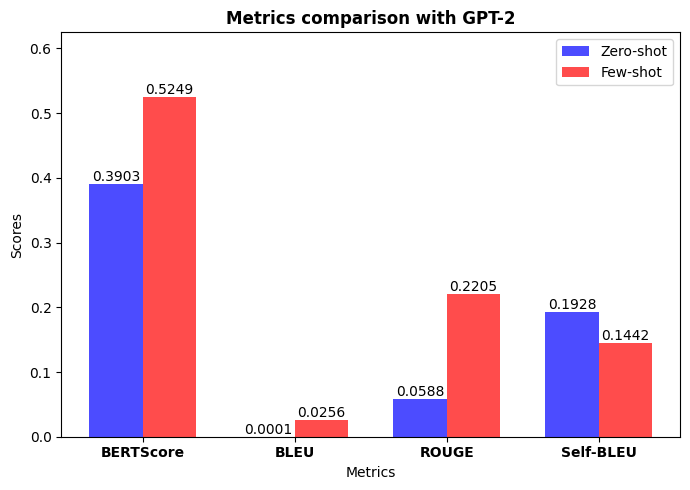

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# métriques
metrics = ["BERTScore", "BLEU", "ROUGE", "Self-BLEU"]

# valeurs (exemple → remplace par les tiennes)
zeroshot_scores = [bert_score_zs, bleu_score_zs, rouge_score_zs, self_bleu_score_zs]
fewshot_scores  = [bert_score_fs, bleu_score_fs, rouge_score_fs, self_bleu_score_fs]

# positions des barres
x = np.arange(len(metrics))
width = 0.35

# plot
plt.figure(figsize=(7,5))

plt.bar(x - width/2, zeroshot_scores, width, label="Zero-shot", color="b", alpha=0.7)
plt.bar(x + width/2, fewshot_scores,  width, label="Few-shot", color='r', alpha=0.7)

for bar in plt.gca().containers:
    plt.bar_label(bar, label_type='edge', fmt='%.4f')

# labels
plt.xlabel("Metrics")
plt.ylabel("Scores")
plt.title("Metrics comparison with GPT-2", fontweight='bold')
plt.xticks(x, metrics, fontweight='bold')
plt.ylim(0, max(max(zeroshot_scores), max(fewshot_scores)) + 0.1)
plt.legend()

plt.tight_layout()
plt.show()

## **Qualitative**

In [41]:
NB_EXAMPLES = 50

df_zs, df_fs = manual_faithfulness(
    eval_dataloader_zeroshot,
    eval_dataloader_fewshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    nb_examples=NB_EXAMPLES
)


In [42]:
df = pd.merge(df_zs.head(NB_EXAMPLES), df_fs.head(NB_EXAMPLES), \
              on=["table", "label"], suffixes=("_zs", "_fs"))
print(len(df))

50


In [43]:
df

,table,label,pred_zs,pred_fs
0,# : 76 | Took Office : Daniel Henry Chamberlai...,Daniel Henry Chamberlain was the 76th Governor...,"box | 1200 Sport : 4-speed-manual, front wheel...","The first President of Tong'an, Daniel Henry C..."
1,Year : 2016 | Title : Kids in Love | Role : Ev...,Alma Jodorowsky had the role of Evelyn in 2016...,Year : 2012 | Year : 2013 | Year : 2014 | Year...,Evelyn is a young girl who is a member of the ...
2,TOTAL : 119,"In his rookie season, Hawk led with 119 total ...",Society | Venue : 1st | Position : Marathon | ...,Järvenpää played 119 games for the NHL.\n\nTab...
3,Name : Peter II the Simple (Pêr II) 1450–1457 ...,"At the very end of his life, Arthur III became...",": The Grateful Dead • | Date : September 3, 19...","The population of Seffner was 6,579 at the 201..."
4,Speaker : Ralph J. Parker,Ralph J. Parker was a Minnesota politician and...,"the end of the first week of the PPV event, an...",Ralph J. Parker was a member of the Houston Ae...
5,Year : 2016 | Host City : Da Nang | Host Natio...,"The last Asian Beach Games was held in Danang,...",is a comedy opera about a young woman who is f...,"In 2016, Auenheim had 872 inhabitants.\n\nTabl..."
6,Year : 2012 | Title : Person of Interest | Rol...,"In 2012, Julian Sands played as Alistair Wesle...",-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19...,Alistair Wesley is a member of the Alistair We...
7,Year : 2005 | Title : Coach Carter | Role : Do...,"In 2005, Adrienne Bailon starred in Coach Cart...",: 1 | col_2 : 1 | col_3 : 1 | col_4 : 1 | col_...,Coach Carter was a coach for the World Wrestli...
8,Name : John L. Estrada,John Learie Estrada is the United States Ambas...,: : 13. | River : Mackenzie–Slave–Peace–Finla...,.6 (100.2) | Year : 1993 | Race Distance : 300...
9,GP : 32 | RPG : 4.8 | APG : 2.3 | PPG : 23.5,"Trey Johnson averaged 23.5 points, 4.8 rebound...",", a young woman, is playing for the Australian...","In 2011, the population of Korissia was 32 at ..."


#